In [1]:
import os
import numpy as np
import efficientnet.tfkeras
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model, model_from_json
from tensorflow.keras import optimizers
 
os.environ["CUDA_VISIBLE_DEVICES"]= ""

In [2]:
modeldir = "/media/tohn/HDD2/Model_unlearn/ResNet152v2Model/MLorigin_USAI/R1_balanced/transfer/models"
path_model = f"{modeldir}/modelResNet152v2_MLorigin_USAI_transfer-R1_balanced.h5"
model = load_model(path_model)
height = width = model.input_shape[1]
input_shape = (height, width, 3)
print(input_shape)
print("*"*125)
model.summary()

(224, 224, 3)
*****************************************************************************************************************************
Model: "ResNet152v2_USAI15AB"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
conv1_pad (ZeroPadding2D)       (None, 230, 230, 3)  0           input_1[0][0]                    
__________________________________________________________________________________________________
conv1_conv (Conv2D)             (None, 112, 112, 64) 9472        conv1_pad[0][0]                  
__________________________________________________________________________________________________
pool1_pad (ZeroPadding2D)       (None,

In [3]:
# validation
import pandas as pd
base_dir = '/media/tohn/SSD/Images/Image1'
dataframe = pd.read_csv( '/media/tohn/HDD/VISION_dataset/Valdf_fold3_v2.csv')#แก้
validation_dir = os.path.join(base_dir, 'test')

#Train
train_df = pd.read_csv( '/media/tohn/HDD/VISION_dataset/Traindf_fold4_8_v2.csv')#แก้
base_dir = '/media/tohn/SSD/Images/Image1'
os.chdir(base_dir)
train_dir = os.path.join(base_dir, 'train')

In [4]:
import pandas as pd
df0 = pd.read_csv('/media/tohn/HDD/VISION_dataset/Testdf_fold1_2_v1.csv')
print(df0 .shape)
dataframe = df0[(df0['Path Crop']!='None' )&(df0['Path Crop']!='Nan')]
print(dataframe.shape)
# print('Normal: ',dataframe[dataframe['Class']=='Normal'].shape)
# print('Abnormal: ',dataframe[dataframe['Class']=='Abnormal'].shape)
dataframe.head(5)

(1312, 27)
(1312, 27)


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Rwidth,Rheight,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label
0,111,40,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,0.513514,0.346614,AB01,NaN,NaN,False,Test,P1,AB01 P1 C040.JPG,P1
1,112,40,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,0.560377,0.428287,AB01,NaN,NaN,False,Test,P2,AB01 P2 C040.JPG,P2
2,113,40,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,0.667984,0.711155,AB01,NaN,NaN,False,Test,P4,AB01 P4-1 C040.JPG,P4
3,114,40,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,2,MildFattyLiver,...,0.690385,0.653386,AB01,NaN,NaN,False,Test,P6,AB01 P5-1 C040.JPG,P6
4,115,40,P3,P31,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,0.672515,0.625498,AB01,NaN,NaN,False,Test,P3,AB01 P3-1 C040.JPG,P3


In [5]:
len(set(dataframe['Sub_class_New']))

15

In [6]:
batch_size = 16

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
      rescale=1./255,
      rotation_range=30,
      width_shift_range=0.2,
      height_shift_range=0.2,
      brightness_range=[0.5,1.5],
      shear_range=0.4,
      zoom_range=0.2,
      horizontal_flip=False,
      fill_mode='nearest')

train_generator = train_datagen.flow_from_dataframe(
        dataframe = dataframe,
        directory = train_dir,
        x_col = 'Path Crop',
        y_col = 'Sub_class_New',
        target_size = (height, width),
        batch_size=batch_size,
        color_mode= 'rgb',
        class_mode='categorical')

#label
labels = (train_generator.class_indices)
labels = dict((v,k.replace("C","")) for k,v in labels.items())
print(labels)

Found 1312 validated image filenames belonging to 15 classes.
{0: 'AB01', 1: 'AB02', 2: 'AB03', 3: 'AB04', 4: 'AB05', 5: 'AB06', 6: 'AB07', 7: 'AB081', 8: 'AB082', 9: 'AB083', 10: 'AB09', 11: 'AB10', 12: 'AB11', 13: 'AB12', 14: 'Normal'}


# Prediction

In [7]:
from tensorflow.keras.preprocessing import image
def predict_image(img_path):
    # Read the image and resize it
    img = image.load_img(img_path, target_size=(height, width))
    # Convert it to a Numpy array with target shape.
    x = image.img_to_array(img)
    # Reshape
    x = x.reshape((1,) + x.shape)
    x /= 255.
    result = model.predict([x])
    
    return result[0]

In [8]:
#Predict
pred_list = list()
prob_list = list()
img_path=dataframe['Path Crop'].tolist()
for i in range(0,len(img_path)):
    print("Predicted Image :", i+1)
    predict = predict_image(img_path[i])
    result = np.argmax(predict)
    pred_list.append(labels[result])
    prob_list.append(predict[result])

Predicted Image : 1
Predicted Image : 2
Predicted Image : 3
Predicted Image : 4
Predicted Image : 5
Predicted Image : 6
Predicted Image : 7
Predicted Image : 8
Predicted Image : 9
Predicted Image : 10
Predicted Image : 11
Predicted Image : 12
Predicted Image : 13
Predicted Image : 14
Predicted Image : 15
Predicted Image : 16
Predicted Image : 17
Predicted Image : 18
Predicted Image : 19
Predicted Image : 20
Predicted Image : 21
Predicted Image : 22
Predicted Image : 23
Predicted Image : 24
Predicted Image : 25
Predicted Image : 26
Predicted Image : 27
Predicted Image : 28
Predicted Image : 29
Predicted Image : 30
Predicted Image : 31
Predicted Image : 32
Predicted Image : 33
Predicted Image : 34
Predicted Image : 35
Predicted Image : 36
Predicted Image : 37
Predicted Image : 38
Predicted Image : 39
Predicted Image : 40
Predicted Image : 41
Predicted Image : 42
Predicted Image : 43
Predicted Image : 44
Predicted Image : 45
Predicted Image : 46
Predicted Image : 47
Predicted Image : 48
P

Predicted Image : 380
Predicted Image : 381
Predicted Image : 382
Predicted Image : 383
Predicted Image : 384
Predicted Image : 385
Predicted Image : 386
Predicted Image : 387
Predicted Image : 388
Predicted Image : 389
Predicted Image : 390
Predicted Image : 391
Predicted Image : 392
Predicted Image : 393
Predicted Image : 394
Predicted Image : 395
Predicted Image : 396
Predicted Image : 397
Predicted Image : 398
Predicted Image : 399
Predicted Image : 400
Predicted Image : 401
Predicted Image : 402
Predicted Image : 403
Predicted Image : 404
Predicted Image : 405
Predicted Image : 406
Predicted Image : 407
Predicted Image : 408
Predicted Image : 409
Predicted Image : 410
Predicted Image : 411
Predicted Image : 412
Predicted Image : 413
Predicted Image : 414
Predicted Image : 415
Predicted Image : 416
Predicted Image : 417
Predicted Image : 418
Predicted Image : 419
Predicted Image : 420
Predicted Image : 421
Predicted Image : 422
Predicted Image : 423
Predicted Image : 424
Predicted 

Predicted Image : 753
Predicted Image : 754
Predicted Image : 755
Predicted Image : 756
Predicted Image : 757
Predicted Image : 758
Predicted Image : 759
Predicted Image : 760
Predicted Image : 761
Predicted Image : 762
Predicted Image : 763
Predicted Image : 764
Predicted Image : 765
Predicted Image : 766
Predicted Image : 767
Predicted Image : 768
Predicted Image : 769
Predicted Image : 770
Predicted Image : 771
Predicted Image : 772
Predicted Image : 773
Predicted Image : 774
Predicted Image : 775
Predicted Image : 776
Predicted Image : 777
Predicted Image : 778
Predicted Image : 779
Predicted Image : 780
Predicted Image : 781
Predicted Image : 782
Predicted Image : 783
Predicted Image : 784
Predicted Image : 785
Predicted Image : 786
Predicted Image : 787
Predicted Image : 788
Predicted Image : 789
Predicted Image : 790
Predicted Image : 791
Predicted Image : 792
Predicted Image : 793
Predicted Image : 794
Predicted Image : 795
Predicted Image : 796
Predicted Image : 797
Predicted 

Predicted Image : 1121
Predicted Image : 1122
Predicted Image : 1123
Predicted Image : 1124
Predicted Image : 1125
Predicted Image : 1126
Predicted Image : 1127
Predicted Image : 1128
Predicted Image : 1129
Predicted Image : 1130
Predicted Image : 1131
Predicted Image : 1132
Predicted Image : 1133
Predicted Image : 1134
Predicted Image : 1135
Predicted Image : 1136
Predicted Image : 1137
Predicted Image : 1138
Predicted Image : 1139
Predicted Image : 1140
Predicted Image : 1141
Predicted Image : 1142
Predicted Image : 1143
Predicted Image : 1144
Predicted Image : 1145
Predicted Image : 1146
Predicted Image : 1147
Predicted Image : 1148
Predicted Image : 1149
Predicted Image : 1150
Predicted Image : 1151
Predicted Image : 1152
Predicted Image : 1153
Predicted Image : 1154
Predicted Image : 1155
Predicted Image : 1156
Predicted Image : 1157
Predicted Image : 1158
Predicted Image : 1159
Predicted Image : 1160
Predicted Image : 1161
Predicted Image : 1162
Predicted Image : 1163
Predicted I

In [9]:
dataframe['category'] = pred_list
dataframe['Prob'] = prob_list
dataframe.head()

,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label,category,Prob
0,111,40,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P1,AB01 P1 C040.JPG,P1,AB02,0.557718
1,112,40,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P2,AB01 P2 C040.JPG,P2,AB01,0.384347
2,113,40,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P4,AB01 P4-1 C040.JPG,P4,AB02,0.860169
3,114,40,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P6,AB01 P5-1 C040.JPG,P6,AB02,0.609175
4,115,40,P3,P31,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P3,AB01 P3-1 C040.JPG,P3,AB02,0.604500


In [10]:
dataframe.to_csv("/home/kannika/code/Result_modelResNet152v2_MLorigin_USAI_transfer-R1_balanced.csv")

# Evaluation

In [11]:
data_train = dataframe
#เช็คคลาสใน Predicted
pred_class = set(data_train['category'])
print('Predicted : ',len(pred_class))
print(pred_class)
#เช็คคลาสใน Actual
classe = set(data_train['Sub_class_New'])
print('Actual : ',len(classe))
print(classe)

Predicted :  15
{'AB02', 'AB03', 'AB081', 'AB11', 'Normal', 'AB082', 'AB05', 'AB06', 'AB09', 'AB10', 'AB04', 'AB083', 'AB12', 'AB01', 'AB07'}
Actual :  15
{'AB02', 'AB03', 'AB081', 'AB11', 'Normal', 'AB082', 'AB05', 'AB06', 'AB09', 'AB10', 'AB04', 'AB083', 'AB12', 'AB01', 'AB07'}


In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix
act = data_train['Sub_class_New'].array
pred = data_train['category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 52.05792682926829%
              precision    recall  f1-score   support

        AB01       0.26      0.54      0.35        74
        AB02       0.23      0.19      0.21        59
        AB03       0.19      0.89      0.32        19
        AB04       0.40      0.55      0.46        38
        AB05       0.36      0.69      0.47        29
        AB06       0.29      0.48      0.36        21
        AB07       0.17      0.43      0.25        21
       AB081       0.35      0.28      0.31        32
       AB082       0.30      0.43      0.35        28
       AB083       0.07      0.09      0.08        11
        AB09       0.20      0.62      0.30        26
        AB10       0.09      0.40      0.14        10
        AB11       0.38      0.71      0.50        55
        AB12       0.63      0.69      0.66        32
      Normal       0.94      0.53      0.68       857

    accuracy                           0.52      1312
   macro avg       0.32      0.50      

Text(0.5, 21.5, 'Predicted label')

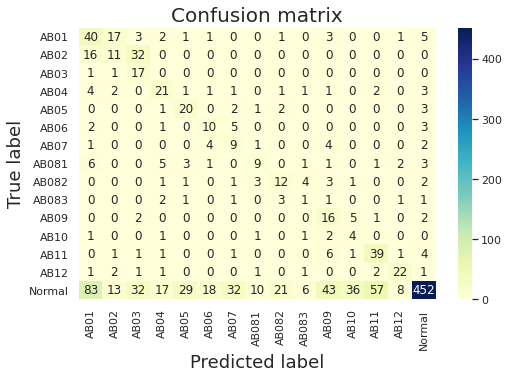

In [13]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)

In [14]:
# act= p1['Sub_class_New'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
act= data_train['Sub_class_New'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
pred = data_train['category'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 66.92073170731707%
              precision    recall  f1-score   support

           0       0.94      0.53      0.68       857
           1       0.51      0.94      0.66       455

    accuracy                           0.67      1312
   macro avg       0.73      0.73      0.67      1312
weighted avg       0.79      0.67      0.67      1312



452 405 29 426


Text(48.5, 0.5, 'True label')

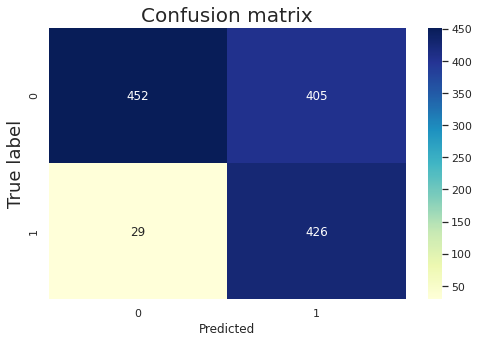

In [15]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)
TN, FP, FN, TP = confusion_matrix(act, pred).ravel()
print(TN, FP, FN, TP)
#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)

In [16]:
Sub_class_New = list(set(dataframe['Sub_class_New']))

for i in range(len(Sub_class_New)):
    df = dataframe[dataframe['Sub_class_New'] == Sub_class_New[i]]
    
    act = df['Sub_class_New'].array
    pred = df['category'].array

    cmat = confusion_matrix(act, pred)
    print('######', Sub_class_New[i])
#     print(cmat)
#     print(classification_report(act, pred))
    
    print('classifier accuracy = {}% \n'.format((np.trace(cmat))/(np.sum(cmat))))

###### AB02
classifier accuracy = 0.1864406779661017% 

###### AB03
classifier accuracy = 0.8947368421052632% 

###### AB081
classifier accuracy = 0.28125% 

###### AB11
classifier accuracy = 0.7090909090909091% 

###### Normal
classifier accuracy = 0.5274212368728122% 

###### AB082
classifier accuracy = 0.42857142857142855% 

###### AB05
classifier accuracy = 0.6896551724137931% 

###### AB06
classifier accuracy = 0.47619047619047616% 

###### AB09
classifier accuracy = 0.6153846153846154% 

###### AB10
classifier accuracy = 0.4% 

###### AB04
classifier accuracy = 0.5526315789473685% 

###### AB083
classifier accuracy = 0.09090909090909091% 

###### AB12
classifier accuracy = 0.6875% 

###### AB01
classifier accuracy = 0.5405405405405406% 

###### AB07
classifier accuracy = 0.42857142857142855% 



# Exclude Normal classes

In [28]:
dataframe0_ = dataframe[(dataframe["Sub_class_New"]!="Normal") & (dataframe['category']!="Normal")].reset_index(drop=True)
print(dataframe0_.shape)
dataframe0_

(426, 29)


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label,category,Prob
0,111,40,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P1,AB01 P1 C040.JPG,P1,AB02,0.557718
1,112,40,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P2,AB01 P2 C040.JPG,P2,AB01,0.384347
2,113,40,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P4,AB01 P4-1 C040.JPG,P4,AB02,0.860169
3,114,40,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P6,AB01 P5-1 C040.JPG,P6,AB02,0.609175
4,115,40,P3,P31,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P3,AB01 P3-1 C040.JPG,P3,AB02,0.604500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,2247,301,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,1,RenalCyst,...,AB11,NaN,NaN,False,Test,P12,FP D P7-2 Case 143.JPG.png,P12,AB09,0.817788
422,2253,300,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,1,Renalstones,...,AB11,NaN,NaN,False,Test,P12,FP D P7-2 Case 142.JPG.png,P12,AB02,0.433466
423,2265,361,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,1,Hydronephrosis,...,AB11,Easy,Hard,False,Test,P12,FP D P7-2 Case 203.JPG.png,P12,AB11,0.527697
424,2269,343,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,2,Hydronephrosis,...,AB11,NaN,NaN,False,Test,P12,FP D P7-2 Case 185.JPG.png,P12,AB11,0.978242


In [29]:
data_train = dataframe0_
#เช็คคลาสใน Predicted
pred_class = set(data_train['category'])
print('Predicted : ',len(pred_class))
print(pred_class)
#เช็คคลาสใน Actual
classe = set(data_train['Sub_class_New'])
print('Actual : ',len(classe))
print(classe)

Predicted :  14
{'AB02', 'AB03', 'AB081', 'AB11', 'AB082', 'AB05', 'AB06', 'AB09', 'AB10', 'AB04', 'AB083', 'AB12', 'AB01', 'AB07'}
Actual :  14
{'AB02', 'AB03', 'AB081', 'AB11', 'AB082', 'AB05', 'AB06', 'AB09', 'AB10', 'AB04', 'AB083', 'AB12', 'AB01', 'AB07'}


In [30]:
import numpy as np
from sklearn.metrics import confusion_matrix

act = data_train['Sub_class_New'].array
pred = data_train['category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 54.225352112676056%
              precision    recall  f1-score   support

        AB01       0.56      0.58      0.57        69
        AB02       0.32      0.19      0.24        59
        AB03       0.30      0.89      0.45        19
        AB04       0.58      0.60      0.59        35
        AB05       0.74      0.77      0.75        26
        AB06       0.59      0.56      0.57        18
        AB07       0.45      0.47      0.46        19
       AB081       0.56      0.31      0.40        29
       AB082       0.63      0.46      0.53        26
       AB083       0.11      0.10      0.11        10
        AB09       0.43      0.67      0.52        24
        AB10       0.36      0.40      0.38        10
        AB11       0.87      0.76      0.81        51
        AB12       0.81      0.71      0.76        31

    accuracy                           0.54       426
   macro avg       0.52      0.53      0.51       426
weighted avg       0.56      0.54     

Text(0.5, 21.5, 'Predicted label')

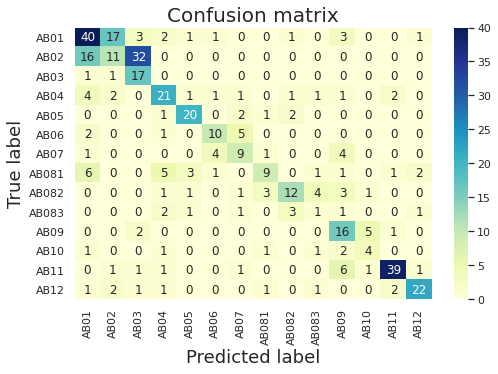

In [31]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)